In [3]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
from xarray.computation.ops import fillna

url = "https://saddam-teacher-api.onrender.com/students/dirty"
token = "saddam_teacher"

response = requests.get(url, params={'token': token})
data = response.json()
df = pd.DataFrame(data)
df

,ball,guruh,ism,shahar,student_id,year,yosh
0,65.0,B1,Vali,Samarqand,1,2024,18.0
1,52.0,B2,Vali,Toshkent,2,2024,19.0
2,85.0,A1,Husan,Samarqand,3,2025,21.0
3,50.0,B1,Husan,Samarqand,4,2025,25.0
4,63.0,A2,Jasur,Buxoro,5,2024,22.0
...,...,...,...,...,...,...,...
115,61.0,B1,Sardor,Toshkent,116,2025,25.0
116,75.0,A1,Sardor,Andijon,117,2024,19.0
117,86.0,A2,Ali,Buxoro,118,2024,20.0
118,88.0,B2,Husan,Samarqand,119,2025,19.0


In [23]:
df['ball'] = df['ball'].fillna(df['ball'].median())
df

,ball,guruh,ism,shahar,student_id,year,yosh
0,65.0,B1,Vali,Samarqand,1,2024,18.0
1,52.0,B2,Vali,Toshkent,2,2024,19.0
2,85.0,A1,Husan,Samarqand,3,2025,21.0
3,50.0,B1,Husan,Samarqand,4,2025,25.0
4,63.0,A2,Jasur,Buxoro,5,2024,22.0
...,...,...,...,...,...,...,...
115,61.0,B1,Sardor,Toshkent,116,2025,25.0
116,75.0,A1,Sardor,Andijon,117,2024,19.0
117,86.0,A2,Ali,Buxoro,118,2024,20.0
118,88.0,B2,Husan,Samarqand,119,2025,19.0


In [26]:
df['yosh'] = df['yosh'].fillna(df['yosh'].median())
df['guruh'] = df['guruh'].fillna('Unknown')
# df['ism'] = df['ism'].fillna('Unknown1')
df['ism'] = df['ism'].replace(['',' ','None','null','N/A'],pd.NA).fillna('Bedarak')
df

,ball,guruh,ism,shahar,student_id,year,yosh
0,65.0,B1,Vali,Samarqand,1,2024,18.0
1,52.0,B2,Vali,Toshkent,2,2024,19.0
2,85.0,A1,Husan,Samarqand,3,2025,21.0
3,50.0,B1,Husan,Samarqand,4,2025,25.0
4,63.0,A2,Jasur,Buxoro,5,2024,22.0
...,...,...,...,...,...,...,...
115,61.0,B1,Sardor,Toshkent,116,2025,25.0
116,75.0,A1,Sardor,Andijon,117,2024,19.0
117,86.0,A2,Ali,Buxoro,118,2024,20.0
118,88.0,B2,Husan,Samarqand,119,2025,19.0


In [13]:
df.isna().sum()

ball          0
guruh         0
ism           0
shahar        0
student_id    0
year          0
yosh          0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ball        120 non-null    float64
 1   guruh       120 non-null    object 
 2   ism         120 non-null    object 
 3   shahar      120 non-null    object 
 4   student_id  120 non-null    int64  
 5   year        120 non-null    int64  
 6   yosh        120 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 6.7+ KB


In [35]:
df['yosh'] = df['yosh'].astype(int)
df

,ball,guruh,ism,shahar,student_id,year,yosh
0,65.0,B1,Vali,Samarqand,1,2024,18
1,52.0,B2,Vali,Toshkent,2,2024,19
2,85.0,A1,Husan,Samarqand,3,2025,21
3,50.0,B1,Husan,Samarqand,4,2025,25
4,63.0,A2,Jasur,Buxoro,5,2024,22
...,...,...,...,...,...,...,...
115,61.0,B1,Sardor,Toshkent,116,2025,25
116,75.0,A1,Sardor,Andijon,117,2024,19
117,86.0,A2,Ali,Buxoro,118,2024,20
118,88.0,B2,Husan,Samarqand,119,2025,19


In [36]:
df.to_excel("bazacha.xlsx")

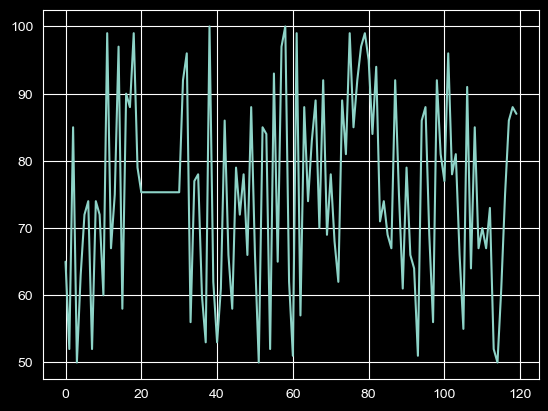

In [37]:
df['ball'].plot()
plt.show()

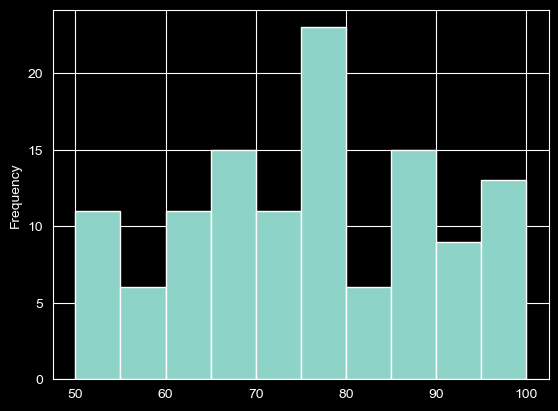

In [38]:
df['ball'].plot(kind='hist')
plt.show()

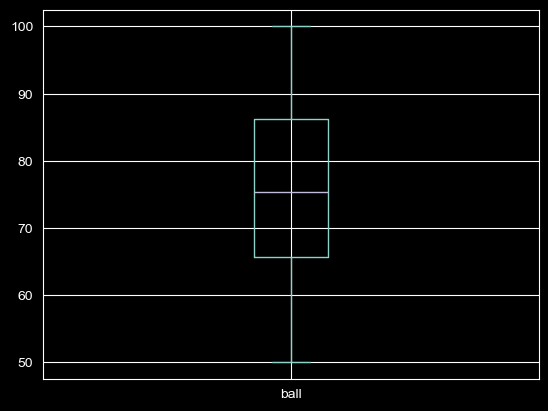

In [39]:
df['ball'].plot(kind='box')
plt.show()

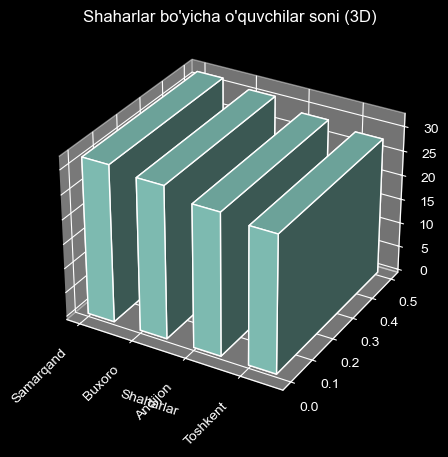

In [47]:
# plt.figure(figsize=(10,4))
# df['shahar'].value_counts().plot(kind='bar')
# plt.title("Shaharlar bo'yicha o'quvchilar soni")
# plt.xlabel("Shaharlar")
# plt.ylabel("Dalbayoblar")
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Ma'lumotlar
counts = df['shahar'].value_counts()
x = np.arange(len(counts))
y = np.zeros(len(counts))
z = np.zeros(len(counts))

dx = np.ones(len(counts)) * 0.5
dy = np.ones(len(counts)) * 0.5
dz = counts.values

# 3D figura
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(x, y, z, dx, dy, dz)

# O'qlar va sarlavha
ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=45, ha='right')
ax.set_xlabel("Shaharlar")
ax.set_ylabel("")
ax.set_zlabel("Dalbayoblar")
ax.set_title("Shaharlar bo'yicha o'quvchilar soni (3D)")

plt.show()
